# Análisis y procesamiento del dataset emocional
Este notebook realiza el procesamiento, limpieza y análisis de un dataset emocional. A continuación se describen los pasos principales.

## 1. Importar librerías
Se importan las librerías necesarias para el análisis y visualización de datos.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL")

## 2. Cargar el archivo de datos
Se lee el archivo Excel con los datos originales y se muestra confirmación de carga.

In [78]:
# Leer el archivo Excel
file_path = 'dataset_emocional.xlsx'
df = pd.read_excel(file_path)
print("Archivo cargado exitosamente.")

Archivo cargado exitosamente.


## 3. Exploración inicial del dataset
Se muestran los tipos de datos y las primeras filas del dataset para una revisión rápida.

In [79]:
print("\nTipos de datos de cada columna:")
print(df.dtypes)

print("\nPrimeras filas del dataset:")
print(df.head())


Tipos de datos de cada columna:
timestamp_unix                            int64
timestamp_iso                            object
participant_full_id                      object
eda_scl_usiemens                        float64
pulse_rate_bpm                          float64
prv_rmssd_ms                            float64
respiratory_rate_brpm                   float64
met                                     float64
temperature_celsius                     float64
activity_counts                         float64
step_counts                             float64
vector_magnitude                        float64
activity_class                           object
activity_intensity                       object
sleep_detection_stage                   float64
eda_scl_usiemens_missing_reason          object
pulse_rate_bpm_missing_reason            object
prv_rmssd_ms_missing_reason              object
respiratory_rate_brpm_missing_reason     object
met_missing_reason                       object
tempera

## 4. Selección de columnas relevantes
Se filtran solo las columnas necesarias para el análisis posterior.

In [80]:
# Filtrar solo las columnas deseadas
desired_columns = [
    'timestamp_unix',
    'eda_scl_usiemens',
    'pulse_rate_bpm',
    'prv_rmssd_ms',
    'respiratory_rate_brpm',
    'met',
    'activity_counts',
    'step_counts',
    'vector_magnitude',
    'activity_class',
    'activity_intensity',
    'sleep_detection_stage',
    'temperature_celsius'
]
df = df[desired_columns]
print(df.head())

df.isnull().sum()

   timestamp_unix  eda_scl_usiemens  pulse_rate_bpm  prv_rmssd_ms  \
0   1753660800000              0.17            51.0     79.585150   
1   1753660860000              0.17            53.0     67.193960   
2   1753660920000              0.17            54.0     61.562310   
3   1753660980000              0.17            54.0     55.245930   
4   1753661040000              0.17            53.0     98.429115   

   respiratory_rate_brpm   met  activity_counts  step_counts  \
0                   14.0  0.95              0.0          0.0   
1                   14.0  0.95              0.0          0.0   
2                   14.0  0.95              0.0          0.0   
3                   15.0  0.95              0.0          0.0   
4                   16.0  0.95              0.0          0.0   

   vector_magnitude activity_class activity_intensity  sleep_detection_stage  \
0               0.0          still          sedentary                  101.0   
1               0.0          still      

timestamp_unix              0
eda_scl_usiemens          140
pulse_rate_bpm            174
prv_rmssd_ms             1176
respiratory_rate_brpm    1161
met                       140
activity_counts           140
step_counts               140
vector_magnitude          140
activity_class            140
activity_intensity        140
sleep_detection_stage     140
temperature_celsius       140
dtype: int64

## 5. Codificación y limpieza de datos
Se eliminan columnas innecesarias, se codifican variables categóricas y se guarda un archivo limpio y codificado.

In [81]:
# Crear un nuevo DataFrame sin las columnas especificadas
columns_to_drop = ['timestamp_iso', 'participant_full_id', 'eda_scl_usiemens_missing_reason', 'pulse_rate_bpm_missing_reason', 'prv_rmssd_ms_missing_reason', 'respiratory_rate_brpm_missing_reason', 'met_missing_reason', 'activity_counts_missing_reason', 'step_counts_missing_reason', 'sleep_detection_stage_missing_reason']
df_filtered = df.drop(columns=columns_to_drop, errors='ignore')

# Aplicar one-hot encoding a la columna 'activity_class'
dummies = pd.get_dummies(df_filtered["activity_class"]).astype(int)
df_filtered = pd.concat([df_filtered, dummies], axis=1)
df_filtered.drop("activity_class", axis=1, inplace=True)

# Aplicar ordinal encoding a la columna 'activity_intensity'
mapping = {
    "sedentary": 0,
    "LPA": 1,
    "MPA": 2,
    "VPA": 3
}
df_filtered["activity_intensity"] = df_filtered["activity_intensity"].map(mapping)

# Aplicar ordinal encoding a la columna 'sleep_detection_stage'
sleep_mapping = {
    0: 0,  # Despierto
    101: 1,  # Fase de sueño 1
    102: 1   # Fase de sueño 2
}
df_filtered["sleep_detection_stage"] = df_filtered["sleep_detection_stage"].map(sleep_mapping)

# Guardar el nuevo DataFrame en un archivo XLSX
output_path = 'dataset_emocional_filtrado_encoded.xlsx'
df_filtered.to_excel(output_path, index=False)

print(f"Nuevo archivo XLSX creado: {output_path}")


print(df_filtered.head())
df_filtered.isnull().sum()

Nuevo archivo XLSX creado: dataset_emocional_filtrado_encoded.xlsx
   timestamp_unix  eda_scl_usiemens  pulse_rate_bpm  prv_rmssd_ms  \
0   1753660800000              0.17            51.0     79.585150   
1   1753660860000              0.17            53.0     67.193960   
2   1753660920000              0.17            54.0     61.562310   
3   1753660980000              0.17            54.0     55.245930   
4   1753661040000              0.17            53.0     98.429115   

   respiratory_rate_brpm   met  activity_counts  step_counts  \
0                   14.0  0.95              0.0          0.0   
1                   14.0  0.95              0.0          0.0   
2                   14.0  0.95              0.0          0.0   
3                   15.0  0.95              0.0          0.0   
4                   16.0  0.95              0.0          0.0   

   vector_magnitude  activity_intensity  sleep_detection_stage  \
0               0.0                 0.0                    1.0   
1

timestamp_unix              0
eda_scl_usiemens          140
pulse_rate_bpm            174
prv_rmssd_ms             1176
respiratory_rate_brpm    1161
met                       140
activity_counts           140
step_counts               140
vector_magnitude          140
activity_intensity        140
sleep_detection_stage     140
temperature_celsius       140
generic                     0
still                       0
walking                     0
dtype: int64

## 6. Imputación de datos faltantes
Se realiza interpolación lineal y forward fill para completar valores faltantes y se guarda el archivo actualizado.

In [82]:
# Cargar el archivo XLSX filtrado y codificado
file_path_filtered = 'dataset_emocional_filtrado_encoded.xlsx'
df_filtered_loaded = pd.read_excel(file_path_filtered)

# -----------------------------
# INTERPOLACIÓN LINEAL
# -----------------------------
columns_to_interpolate = [
    'eda_scl_usiemens',
    'pulse_rate_bpm',
    'met',
    'activity_counts',
    'step_counts',
    'temperature_celsius',
    'vector_magnitude'
 ]

for col in columns_to_interpolate:
    if col in df_filtered_loaded.columns:
        df_filtered_loaded[col] = df_filtered_loaded[col].interpolate(method='linear')

# -----------------------------
# FORWARD FILL (ACTUALIZADO)
# -----------------------------
columns_to_ffill = [
    'activity_intensity',
    'sleep_detection_stage'
 ]

for col in columns_to_ffill:
    if col in df_filtered_loaded.columns:
        df_filtered_loaded[col] = df_filtered_loaded[col].ffill()

# -----------------------------
# VERIFICAR DATOS FALTANTES
# -----------------------------
print("\nDatos faltantes por columna (después de imputación):")
print(df_filtered_loaded.isnull().sum())

# -----------------------------
# GUARDAR ARCHIVO ACTUALIZADO
# -----------------------------
output_path_interpolated = 'dataset_emocional_filtrado_encoded.xlsx'
df_filtered_loaded.to_excel(output_path_interpolated, index=False)

print(f"\nArchivo XLSX actualizado: {output_path_interpolated}")


Datos faltantes por columna (después de imputación):
timestamp_unix              0
eda_scl_usiemens            0
pulse_rate_bpm              0
prv_rmssd_ms             1176
respiratory_rate_brpm    1161
met                         0
activity_counts             0
step_counts                 0
vector_magnitude            0
activity_intensity          0
sleep_detection_stage       0
temperature_celsius         0
generic                     0
still                       0
walking                     0
dtype: int64

Archivo XLSX actualizado: dataset_emocional_filtrado_encoded.xlsx


## 7. Visualización de variables en el tiempo
Se grafican las variables principales respecto al tiempo para detectar tendencias y anomalías.

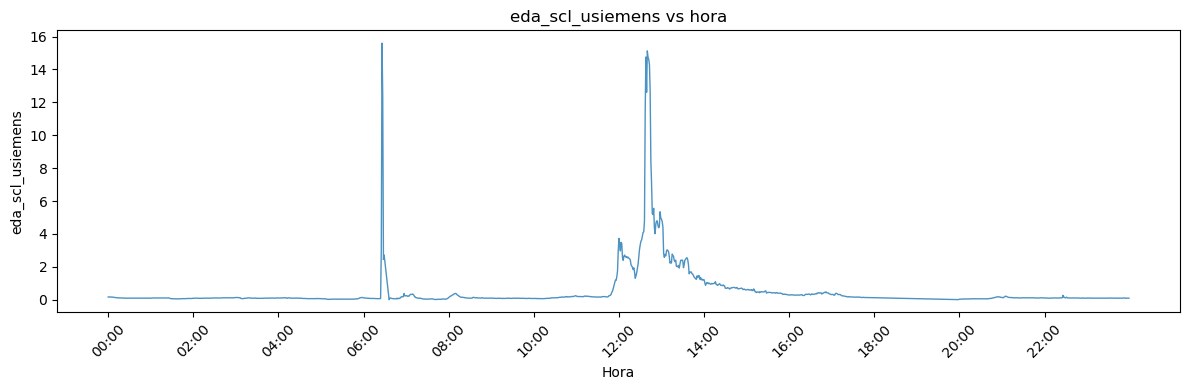

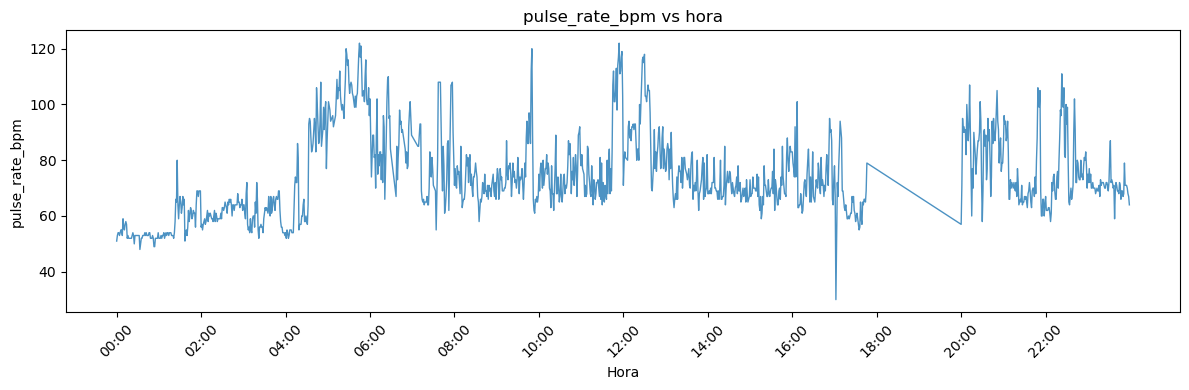

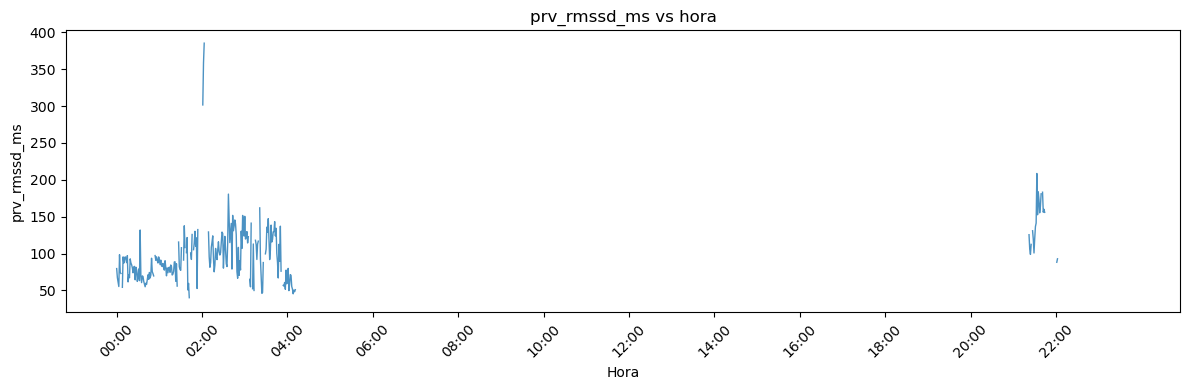

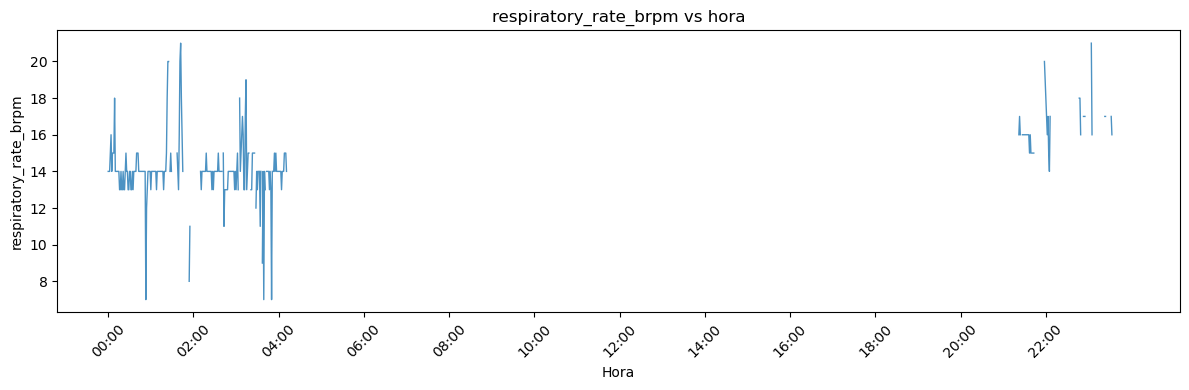

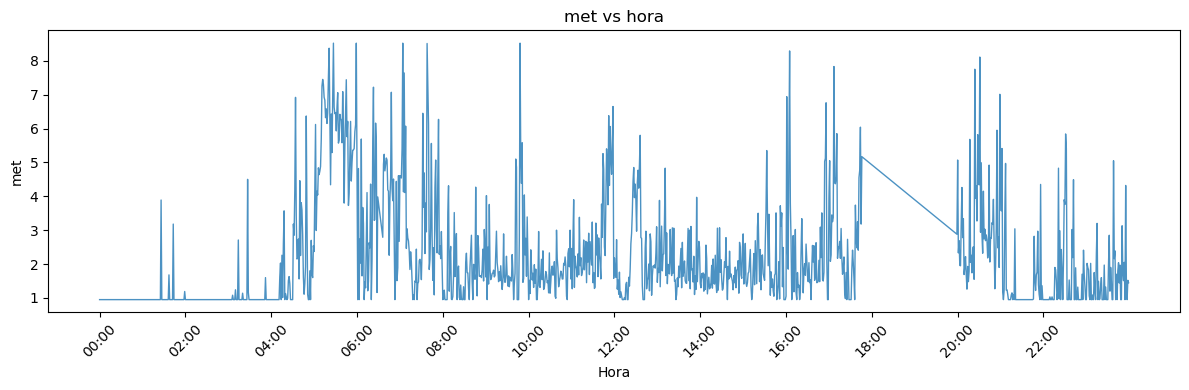

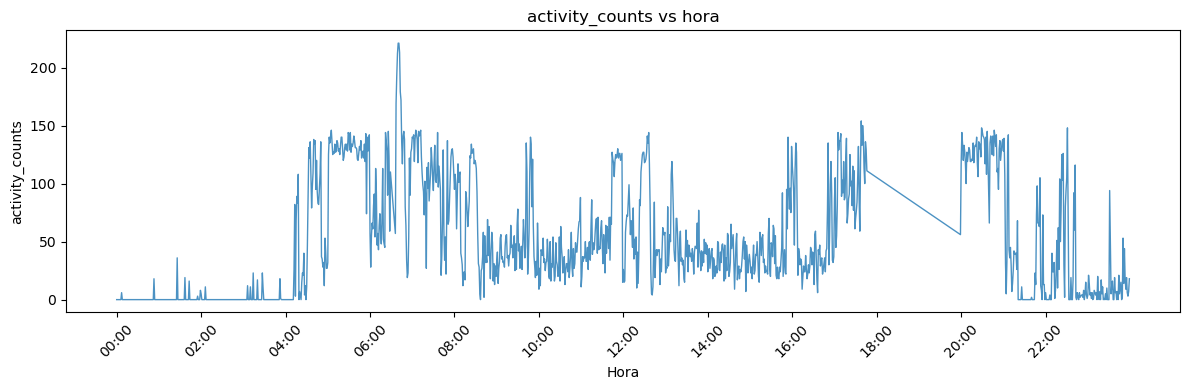

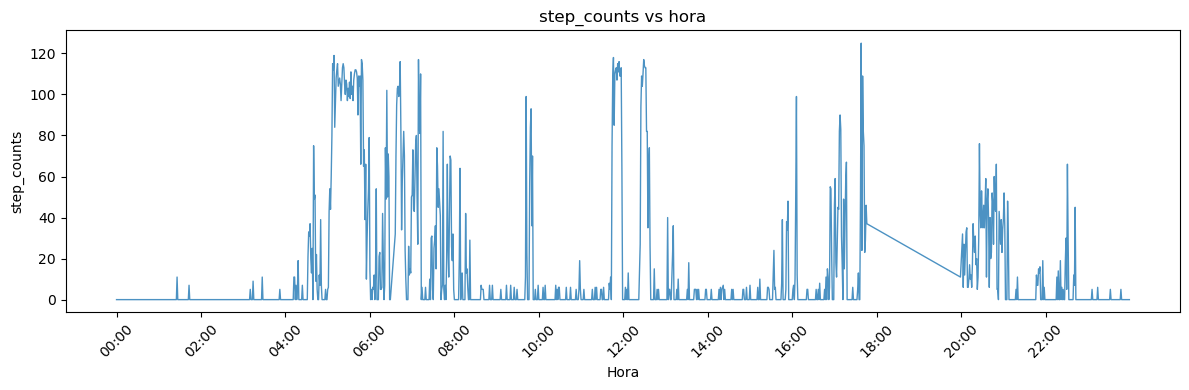

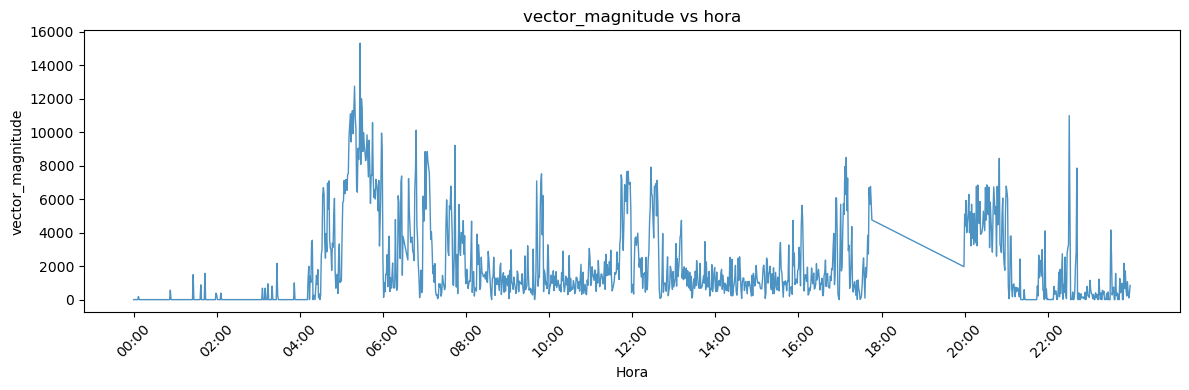

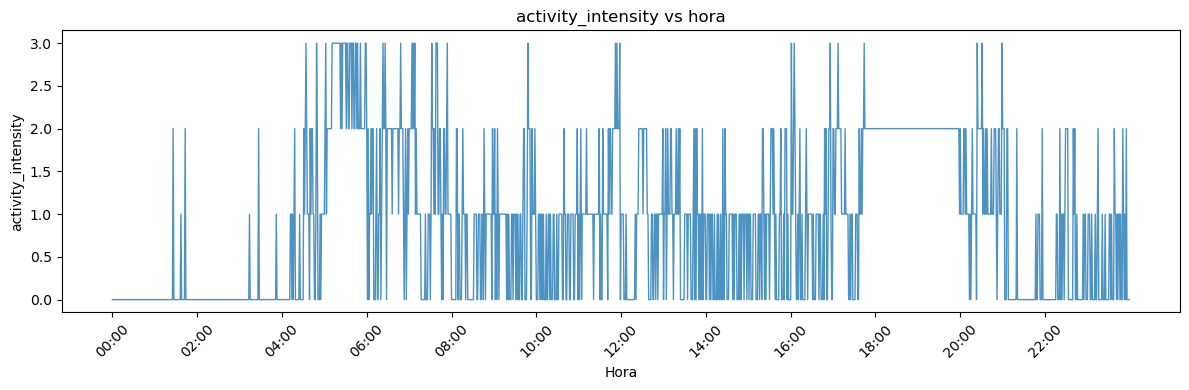

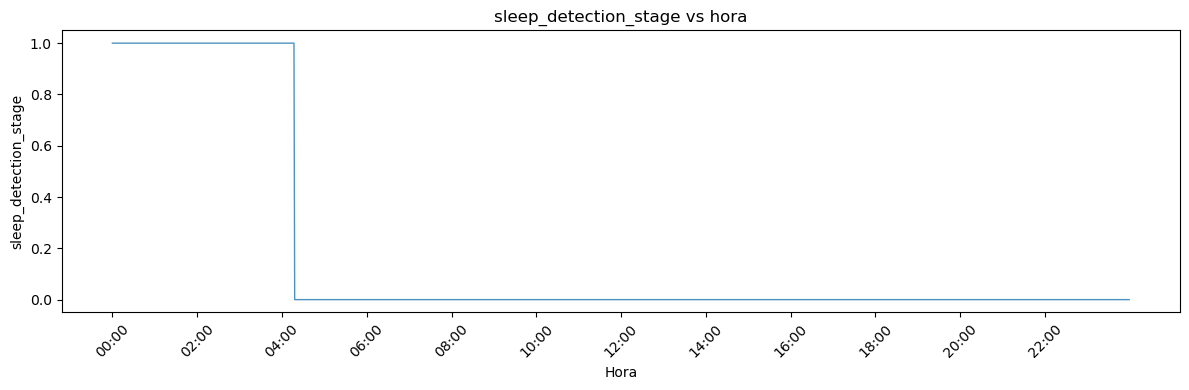

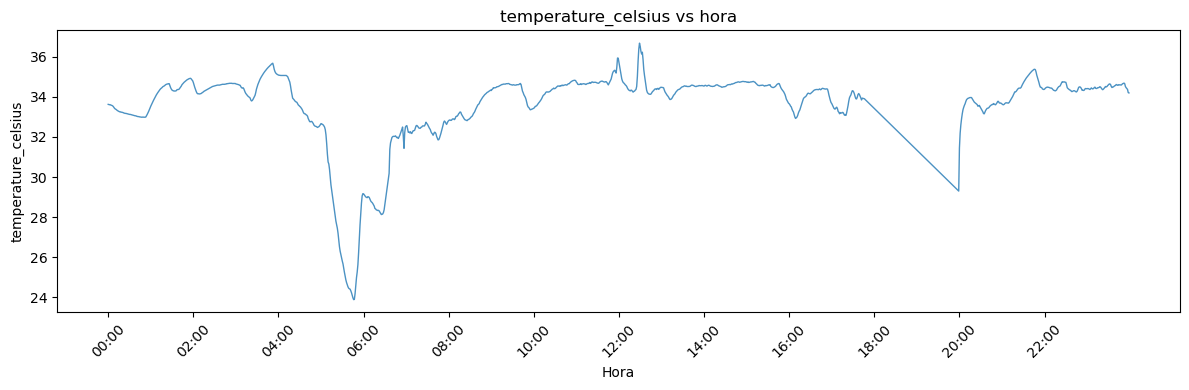

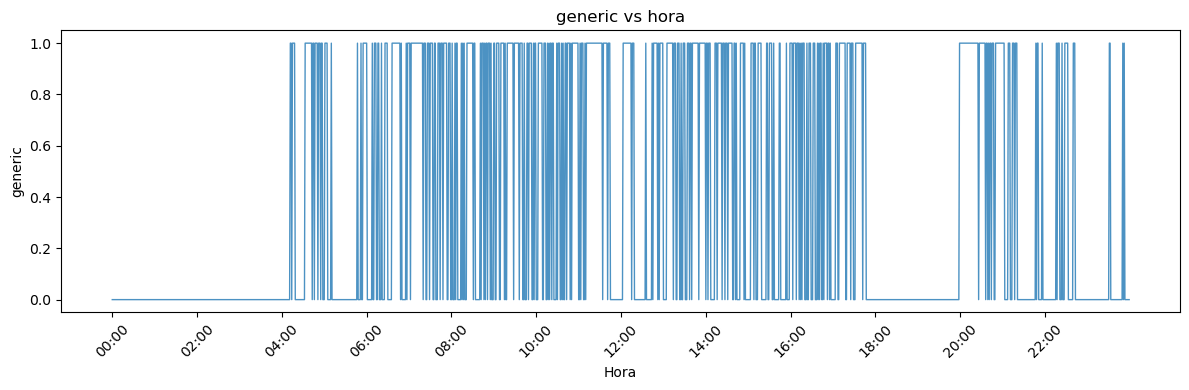

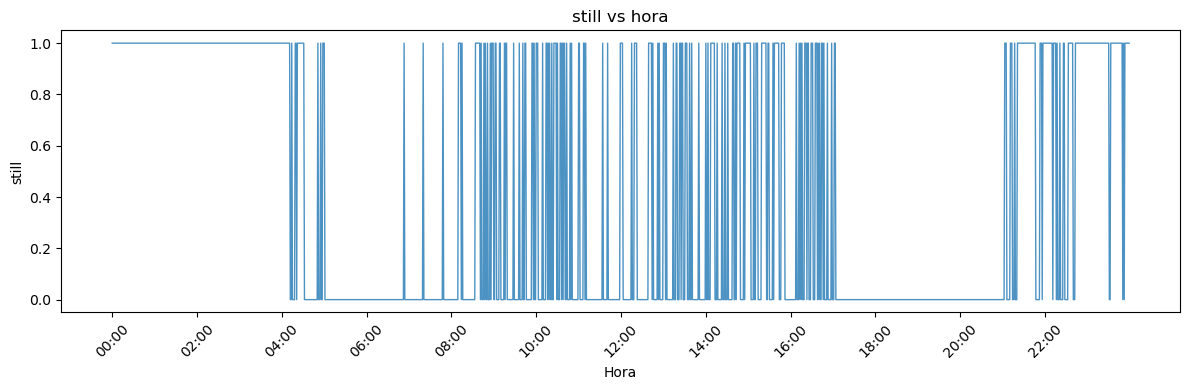

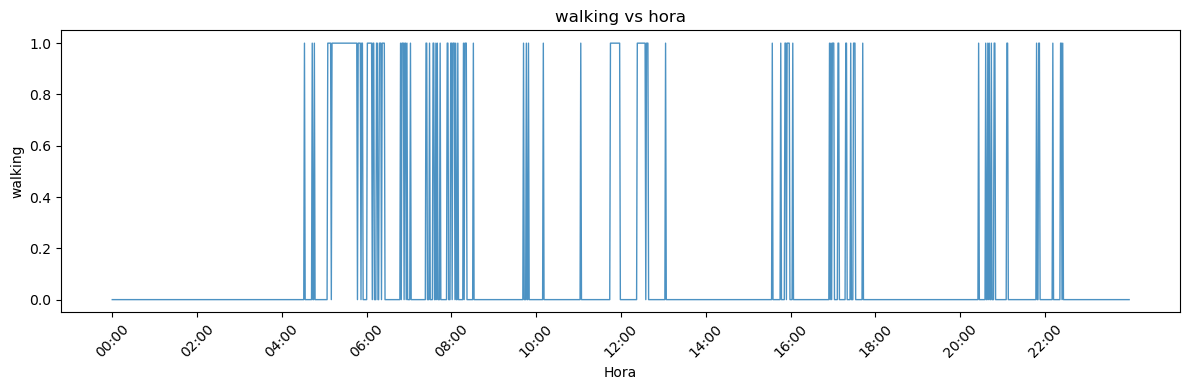

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

timestamp_col = 'timestamp_unix'

if timestamp_col in df_filtered_loaded.columns:

    # Ordenar
    df_filtered_loaded = df_filtered_loaded.sort_values(timestamp_col)

    # Convertir a datetime (milisegundos)
    df_filtered_loaded['timestamp_dt'] = pd.to_datetime(
        df_filtered_loaded[timestamp_col],
        unit='ms'
    )

    # Extraer solo la hora y minuto como string para el eje x
    df_filtered_loaded['hora_minuto'] = df_filtered_loaded['timestamp_dt'].dt.strftime('%H:%M')

    for col in df_filtered_loaded.columns:
        if col in [timestamp_col, 'timestamp_dt', 'hora_minuto']:
            continue

        plt.figure(figsize=(12, 4))

        plt.plot(
            df_filtered_loaded['hora_minuto'],
            df_filtered_loaded[col],
            linestyle='-',
            linewidth=1,
            alpha=0.8
        )

        plt.title(f'{col} vs hora')
        plt.xlabel('Hora')
        plt.ylabel(col)

        # Mostrar solo algunos ticks para que no se sobrecargue
        n = len(df_filtered_loaded)
        step = max(1, n // 12)
        plt.xticks(df_filtered_loaded['hora_minuto'][::step], rotation=45)
        plt.tight_layout()
        plt.show()

else:
    print('La columna timestamp_unix no está presente en df_filtered_loaded.')

## 8. Detección y corrección de outliers
Se detectan valores atípicos según límites fisiológicos y se corrigen mediante clipping.

In [84]:
# Límites fisiológicos
limits = {
    'pulse_rate_bpm': (0, 250),
    'eda_scl_usiemens': (0, 50),
    'step_counts': (0, 300),
    'activity_counts': (0, 100000),
    'vector_magnitude': (0, 50000),
    'met': (0.5, 20),
    'temperature_celsius': (28, 46),     
    'respiratory_rate_brpm': (0, 40),
    'prv_rmssd_ms': (0, 300)
}

file_path_filtered = 'dataset_emocional_filtrado_encoded.xlsx'
df_clean = pd.read_excel(file_path_filtered)

outlier_report = {}

for col, (low, high) in limits.items():
    if col in df_clean.columns:

        # Detectar outliers
        mask_outliers = (df_clean[col] < low) | (df_clean[col] > high)

        count_outliers = mask_outliers.sum()
        total_values = df_clean[col].notna().sum()

        outlier_report[col] = {
            "outliers": int(count_outliers),
            "total": int(total_values),
            "percentage": round(count_outliers / total_values * 100, 2) if total_values > 0 else 0
        }

        # Aplicar clipping (como ya haces)
        df_clean[col] = df_clean[col].clip(lower=low, upper=high)

# Mostrar resultados
for col, info in outlier_report.items():
    print(f"{col}: {info['outliers']} outliers de {info['total']} ({info['percentage']}%)")

# -----------------------------
# GUARDAR ARCHIVO ACTUALIZADO
# -----------------------------
output_path_interpolated = 'dataset_emocional_filtrado_encoded.xlsx'
df_clean.to_excel(output_path_interpolated, index=False)

print(f"\nArchivo XLSX actualizado: {output_path_interpolated}")

pulse_rate_bpm: 0 outliers de 1440 (0.0%)
eda_scl_usiemens: 0 outliers de 1440 (0.0%)
step_counts: 0 outliers de 1440 (0.0%)
activity_counts: 0 outliers de 1440 (0.0%)
vector_magnitude: 0 outliers de 1440 (0.0%)
met: 0 outliers de 1440 (0.0%)
temperature_celsius: 35 outliers de 1440 (2.43%)
respiratory_rate_brpm: 0 outliers de 279 (0.0%)
prv_rmssd_ms: 3 outliers de 264 (1.14%)

Archivo XLSX actualizado: dataset_emocional_filtrado_encoded.xlsx


## 9. Clustering automático con GMM y PCA
Se realiza clustering usando Gaussian Mixture Model (GMM) y reducción de dimensionalidad con PCA. Se selecciona el número óptimo de clusters usando BIC.

Shape original: (1440, 12)
Shape tras dropna: (1440, 12)
n_components de PCA: 6


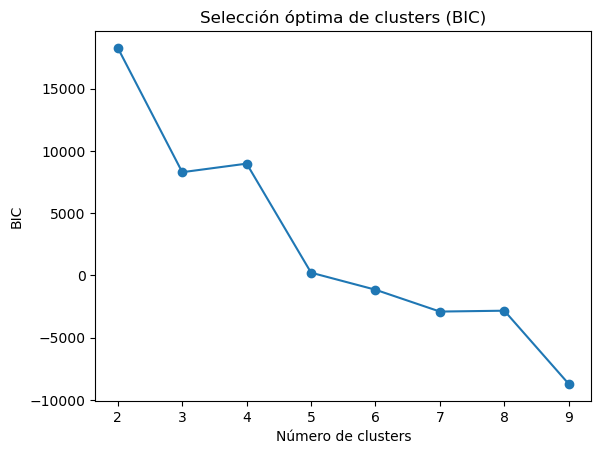

Número óptimo de clusters según BIC: 9

📊 Media de cada cluster:
        eda_scl_usiemens           pulse_rate_bpm                  met  \
                    mean       std           mean        std      mean   
cluster                                                                  
0               0.228673  0.225673      69.598639   5.911936  1.483401   
1               0.112551  0.075511      72.905695  18.687891  2.707381   
2               0.103559  0.020234      58.190678   5.319742  0.950000   
3               1.041553  1.283542      73.949772   7.283261  1.890137   
4               0.737222  1.211942     106.685185   7.594143  5.373472   
5               0.152062  0.107761      83.548110  12.773307  3.030722   
6               4.265298  4.572507      82.335417  11.583235  2.356500   
7               0.075000  0.037386      68.082090   6.279717  4.025000   
8               0.136389  0.094080      79.727431  12.782124  2.910382   

                  activity_counts            s

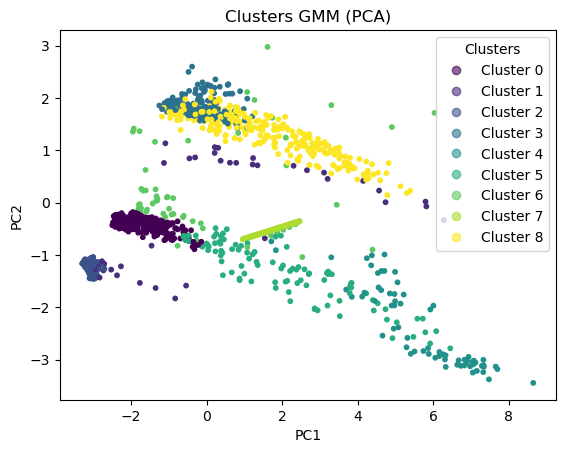


🔍 Probabilidades de pertenencia (primeras filas):
[[0.00000000e+000 2.55380496e-010 1.00000000e+000 0.00000000e+000
  7.63676474e-200 3.85102948e-087 2.20499030e-082 0.00000000e+000
  3.18951479e-165]
 [0.00000000e+000 2.00572362e-010 1.00000000e+000 0.00000000e+000
  1.09273789e-196 1.77175079e-086 3.61805501e-081 0.00000000e+000
  5.71999232e-165]
 [0.00000000e+000 1.90460865e-010 1.00000000e+000 0.00000000e+000
  4.41546851e-195 4.08322331e-086 1.58247890e-080 0.00000000e+000
  8.25771007e-165]
 [0.00000000e+000 1.90460865e-010 1.00000000e+000 0.00000000e+000
  4.41546851e-195 4.08322331e-086 1.58247890e-080 0.00000000e+000
  8.25771007e-165]
 [0.00000000e+000 1.91802227e-010 1.00000000e+000 0.00000000e+000
  1.13970100e-196 1.70834603e-086 3.62617415e-081 0.00000000e+000
  5.63978676e-165]]


In [85]:
# --- CLUSTERING GMM CON OPCIÓN DE PCA MEJORADO ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# =========================
# 1. SELECCIÓN DE FEATURES
# =========================
features = [
    'eda_scl_usiemens', 'pulse_rate_bpm', 'met',
    'activity_counts', 'step_counts', 'vector_magnitude',
    'activity_intensity', 'sleep_detection_stage', 'temperature_celsius',
    'generic', 'still', 'walking'
 ]

file_path_filtered = 'dataset_emocional_filtrado_encoded.xlsx'
df_filtered_loaded = pd.read_excel(file_path_filtered)
X = df_filtered_loaded[features].dropna()

print("Shape original:", df_filtered_loaded[features].shape)
print("Shape tras dropna:", X.shape)

# =========================
# 2. ESCALADO
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 3. PCA (OPCIONAL)
# =========================
use_pca = True  # Cambia a False si no quieres PCA

if use_pca:
    pca = PCA(n_components=0.90)  # conserva 90% de varianza
    X_cluster = pca.fit_transform(X_scaled)
    print("n_components de PCA:", pca.n_components_)
else:
    X_cluster = X_scaled

# =========================
# 4. SELECCIÓN DE K CON BIC
# =========================
bic_scores = []
K_range = range(2, 10)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=5,
        random_state=42
    )
    gmm.fit(X_cluster)
    bic_scores.append(gmm.bic(X_cluster))

# =========================
# 5. GRÁFICO BIC
# =========================
plt.figure()
plt.plot(list(K_range), bic_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('BIC')
plt.title('Selección óptima de clusters (BIC)')
plt.show()

# =========================
# 6. MEJOR K
# =========================
n_clusters = list(K_range)[np.argmin(bic_scores)]
print(f"Número óptimo de clusters según BIC: {n_clusters}")

# =========================
# 7. ENTRENAMIENTO FINAL GMM
# =========================
gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type='full',
    n_init=10,
    random_state=42
)

gmm.fit(X_cluster)

labels = gmm.predict(X_cluster)
probs = gmm.predict_proba(X_cluster)

# =========================
# 8. AÑADIR CLUSTERS AL DF
# =========================
X_result = X.copy()
X_result['cluster'] = labels

# GUARDAR ARCHIVO ACTUALIZADO
cluster_result = X_result.copy()
cluster_result['timestamp_unix '] = df_filtered_loaded['timestamp_unix']
output_path_interpolated = 'dataset_emocional_filtrado_clusters.xlsx'
cluster_result.to_excel(output_path_interpolated, index=False)

# =========================
# 9. ESTADÍSTICAS POR CLUSTER
# =========================
print("\n📊 Media de cada cluster:")
print(X_result.groupby('cluster').agg(['mean', 'std']))

# =========================
# 10. SILHOUETTE SCORE
# =========================
try:
    sil_score = silhouette_score(X_cluster, labels)
    print("\n📈 Silhouette Score:", sil_score)
except:
    print("\n⚠️ No se pudo calcular silhouette score")

# =========================
# 11. VISUALIZACIÓN (PCA)
# =========================
if use_pca and X_cluster.shape[1] >= 2:
    plt.figure()
    scatter = plt.scatter(
        X_cluster[:, 0],
        X_cluster[:, 1],
        c=labels,
        cmap='viridis',
        s=10
    )
    plt.title('Clusters GMM (PCA)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    # Añadir glosario/leyenda para los clusters
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    cluster_labels = [f"Cluster {i}" for i in sorted(set(labels))]
    plt.legend(handles, cluster_labels, title="Clusters", loc="best")
    plt.show()

# =========================
# 12. PROBABILIDADES
# =========================
print("\n🔍 Probabilidades de pertenencia (primeras filas):")
print(probs[:5])

## 10. Interpretacion de clusters

In [86]:
summary = X_result.groupby('cluster').mean()

# calcular percentiles globales
percentiles = X_result.drop(columns='cluster').quantile([0.33, 0.66])

def categorize(value, col):
    if value <= percentiles.loc[0.33, col]:
        return "LOW"
    elif value <= percentiles.loc[0.66, col]:
        return "MED"
    else:
        return "HIGH"
    
interpretable = summary.copy()

for col in summary.columns:
    interpretable[col] = summary[col].apply(lambda x: categorize(x, col))

print(interpretable)

        eda_scl_usiemens pulse_rate_bpm   met activity_counts step_counts  \
cluster                                                                     
0                   HIGH            MED   MED             LOW         MED   
1                    MED            MED  HIGH             MED        HIGH   
2                    MED            LOW   LOW             LOW         LOW   
3                   HIGH            MED   MED             MED         MED   
4                   HIGH           HIGH  HIGH            HIGH        HIGH   
5                    MED           HIGH  HIGH            HIGH        HIGH   
6                   HIGH           HIGH   MED             MED        HIGH   
7                    LOW            MED  HIGH            HIGH        HIGH   
8                    MED           HIGH  HIGH            HIGH        HIGH   

        vector_magnitude activity_intensity sleep_detection_stage  \
cluster                                                             
0             

## 11. Verificar sentido temporal

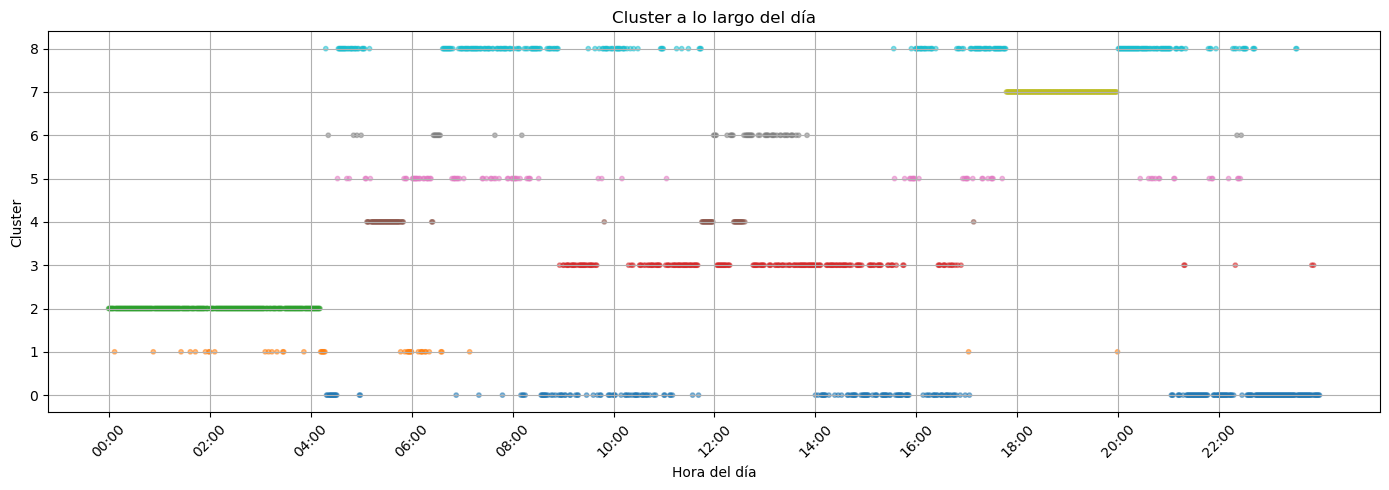

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
file_path_clusters = 'dataset_emocional_filtrado_clusters.xlsx'
df_clusters = pd.read_excel(file_path_clusters)

# Limpiar columnas
df_clusters.columns = df_clusters.columns.str.strip()

x_col = 'timestamp_unix'
y_col = 'cluster'

if x_col in df_clusters.columns and y_col in df_clusters.columns:

    # Convertir a datetime (milisegundos)
    df_clusters['datetime'] = pd.to_datetime(df_clusters[x_col], unit='ms', errors='coerce')

    # Extraer solo la hora y minuto como string para el eje x
    df_clusters['hora_minuto'] = df_clusters['datetime'].dt.strftime('%H:%M')

    plt.figure(figsize=(14, 5))
    plt.scatter(
        df_clusters['hora_minuto'],
        df_clusters[y_col],
        alpha=0.5,
        s=10,
        c=df_clusters[y_col],
        cmap='tab10'
    )

    plt.xlabel('Hora del día')
    plt.ylabel('Cluster')
    plt.title('Cluster a lo largo del día')

    # Mostrar solo algunos ticks para que no se sobrecargue
    n = len(df_clusters)
    step = max(1, n // 12)
    plt.xticks(df_clusters['hora_minuto'][::step], rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print(f'No se encontraron las columnas {x_col} y/o {y_col}')

## EXTRA 1. Clustering GMM con número de clusters fijo
Permite definir manualmente el número de clusters para el modelo GMM y visualizar los resultados.

n_components de PCA: 6

Media de cada cluster (n_clusters=4):
         eda_scl_usiemens  pulse_rate_bpm       met  activity_counts  \
cluster                                                                
0                0.119895       75.276042  2.984366        84.116071   
1                1.195134       85.370703  3.157437        81.082589   
2                0.103559       58.190678  0.950000         0.004237   
3                0.675783       70.849398  1.499307        17.087349   

         step_counts  vector_magnitude  activity_intensity  \
cluster                                                      
0          19.614001       2907.544125            1.288043   
1          32.748661       3393.022321            1.306250   
2           0.000000          0.025424            0.000000   
3           0.635542        616.689759            0.406627   

         sleep_detection_stage   generic     still  walking  
cluster                                                      
0       

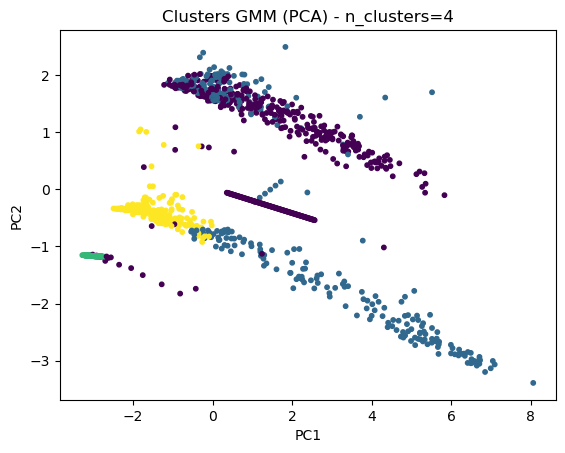


Probabilidades de pertenencia (primeras filas):
[[4.01987355e-016 3.52730361e-162 1.00000000e+000 0.00000000e+000]
 [3.20116839e-016 2.12384073e-161 1.00000000e+000 0.00000000e+000]
 [2.97483799e-016 5.40762977e-161 1.00000000e+000 0.00000000e+000]
 [2.97483799e-016 5.40762977e-161 1.00000000e+000 0.00000000e+000]
 [3.20116839e-016 2.12384073e-161 1.00000000e+000 0.00000000e+000]]


In [88]:
# --- CLUSTERING GMM CON NÚMERO DE CLUSTERS FIJO ---
# Puedes cambiar el valor de n_clusters_manual a cualquier número deseado
n_clusters_manual = 4  # <--- Cambia este valor según lo que necesites

# =========================
# 1. SELECCIÓN DE FEATURES
# =========================
features = [
    'eda_scl_usiemens', 'pulse_rate_bpm', 'met',
    'activity_counts', 'step_counts', 'vector_magnitude',
    'activity_intensity', 'sleep_detection_stage',
    'generic', 'still', 'walking'
 ]

file_path_filtered = 'dataset_emocional_filtrado_encoded.xlsx'
df_filtered_loaded = pd.read_excel(file_path_filtered)
X = df_filtered_loaded[features].dropna()

# =========================
# 2. ESCALADO
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 3. PCA (OPCIONAL)
# =========================
use_pca = True
if use_pca:
    pca = PCA(n_components=0.90)
    X_cluster = pca.fit_transform(X_scaled)
    print("n_components de PCA:", pca.n_components_)
else:
    X_cluster = X_scaled

# =========================
# 4. ENTRENAMIENTO FINAL GMM
# =========================
n_clusters_manual = 4  # <--- Cambia este valor según lo que necesites
gmm_manual = GaussianMixture(
    n_components=n_clusters_manual,
    covariance_type='full',
    n_init=10,
    random_state=42
)
gmm_manual.fit(X_cluster)
labels_manual = gmm_manual.predict(X_cluster)
probs_manual = gmm_manual.predict_proba(X_cluster)

# =========================
# 5. AÑADIR CLUSTERS AL DF
# =========================
X_result_manual = X.copy()
X_result_manual['cluster'] = labels_manual

# =========================
# 6. GUARDAR ARCHIVO ACTUALIZADO
# =========================
cluster_result_manual = X_result_manual.copy()
cluster_result_manual['timestamp_unix'] = df_filtered_loaded['timestamp_unix']
output_path_manual = 'dataset_emocional_filtrado_clusters4.xlsx'
cluster_result_manual.to_excel(output_path_manual, index=False)

# =========================
# 7. ESTADÍSTICAS POR CLUSTER
# =========================
print(f"\nMedia de cada cluster (n_clusters={n_clusters_manual}):")
print(X_result_manual.groupby('cluster').mean())

# =========================
# 8. SILHOUETTE SCORE
# =========================
try:
    sil_score_manual = silhouette_score(X_cluster, labels_manual)
    print("\nSilhouette Score:", sil_score_manual)
except:
    print("\nNo se pudo calcular silhouette score")

# =========================
# 9. VISUALIZACIÓN (PCA)
# =========================
if use_pca and X_cluster.shape[1] >= 2:
    plt.figure()
    plt.scatter(
        X_cluster[:, 0],
        X_cluster[:, 1],
        c=labels_manual,
        cmap='viridis',
        s=10
    )
    plt.title(f'Clusters GMM (PCA) - n_clusters={n_clusters_manual}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

# =========================
# 10. PROBABILIDADES
# =========================
print("\nProbabilidades de pertenencia (primeras filas):")
print(probs_manual[:5])


## 10. Interpretacion de clusters

In [89]:
summary = X_result_manual.groupby('cluster').mean()

# calcular percentiles globales
percentiles = X_result_manual.drop(columns='cluster').quantile([0.33, 0.66])

def categorize(value, col):
    if value <= percentiles.loc[0.33, col]:
        return "LOW"
    elif value <= percentiles.loc[0.66, col]:
        return "MED"
    else:
        return "HIGH"
    
interpretable = summary.copy()

for col in summary.columns:
    interpretable[col] = summary[col].apply(lambda x: categorize(x, col))

print(interpretable)

        eda_scl_usiemens pulse_rate_bpm   met activity_counts step_counts  \
cluster                                                                     
0                    MED            MED  HIGH            HIGH        HIGH   
1                   HIGH           HIGH  HIGH            HIGH        HIGH   
2                    MED            LOW   LOW             LOW         LOW   
3                   HIGH            MED   MED             LOW         MED   

        vector_magnitude activity_intensity sleep_detection_stage generic  \
cluster                                                                     
0                   HIGH               HIGH                  HIGH     MED   
1                   HIGH               HIGH                   LOW     MED   
2                    LOW                LOW                  HIGH     LOW   
3                    MED                MED                   LOW     LOW   

        still walking  
cluster                
0         MED     LOW  
1 

## 11. Verificar sentido temporal

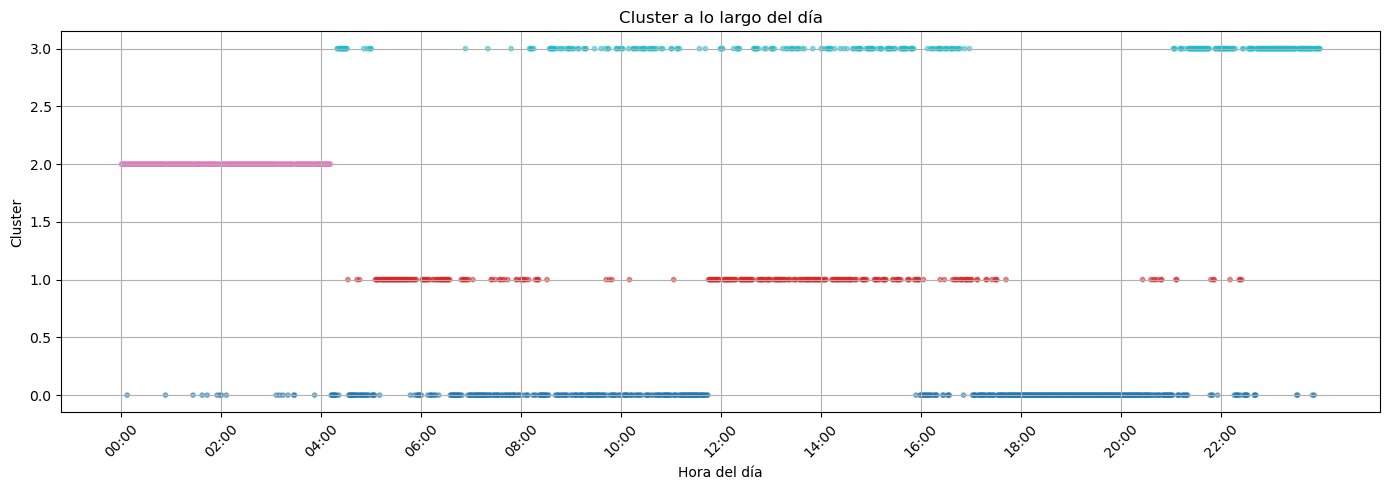

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
file_path_clusters = 'dataset_emocional_filtrado_clusters4.xlsx'
df_clusters = pd.read_excel(file_path_clusters)

# Limpiar columnas
df_clusters.columns = df_clusters.columns.str.strip()

x_col = 'timestamp_unix'
y_col = 'cluster'

if x_col in df_clusters.columns and y_col in df_clusters.columns:

    # Convertir a datetime (milisegundos)
    df_clusters['datetime'] = pd.to_datetime(df_clusters[x_col], unit='ms', errors='coerce')

    # Extraer solo la hora y minuto como string para el eje x
    df_clusters['hora_minuto'] = df_clusters['datetime'].dt.strftime('%H:%M')

    plt.figure(figsize=(14, 5))
    plt.scatter(
        df_clusters['hora_minuto'],
        df_clusters[y_col],
        alpha=0.5,
        s=10,
        c=df_clusters[y_col],
        cmap='tab10'
    )

    plt.xlabel('Hora del día')
    plt.ylabel('Cluster')
    plt.title('Cluster a lo largo del día')

    # Mostrar solo algunos ticks para que no se sobrecargue
    n = len(df_clusters)
    step = max(1, n // 12)
    plt.xticks(df_clusters['hora_minuto'][::step], rotation=45)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print(f'No se encontraron las columnas {x_col} y/o {y_col}')

## EXTRA 2. Visualización de combinaciones de componentes principales
Se grafican automáticamente todas las combinaciones de componentes principales (PCA) para analizar la separación de los clusters.

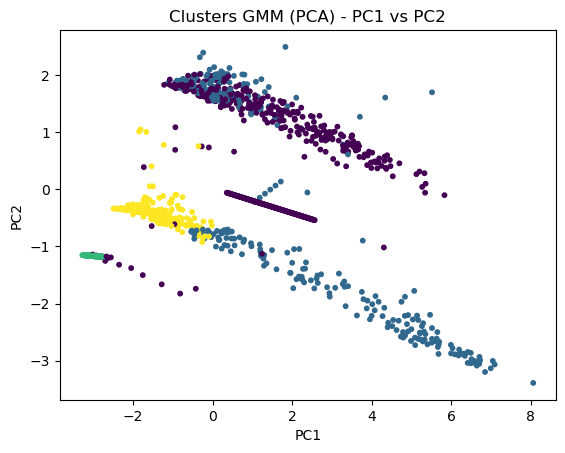

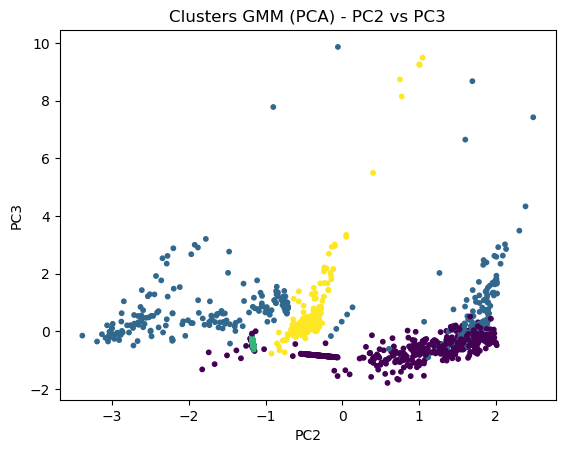

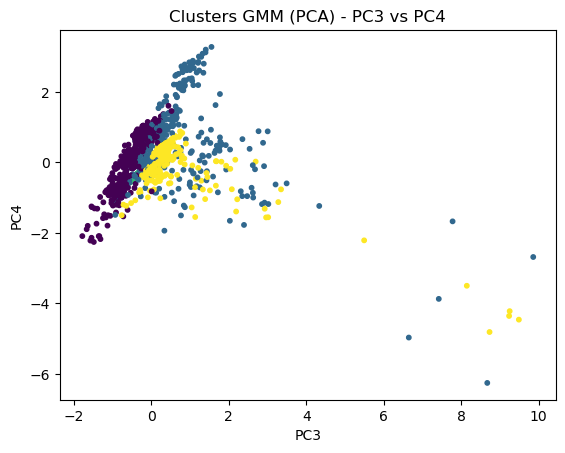

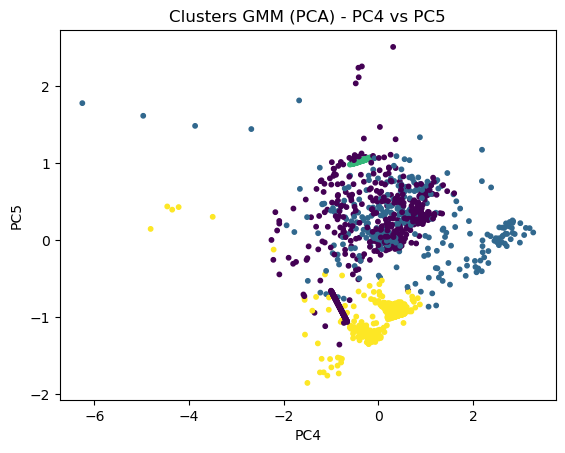

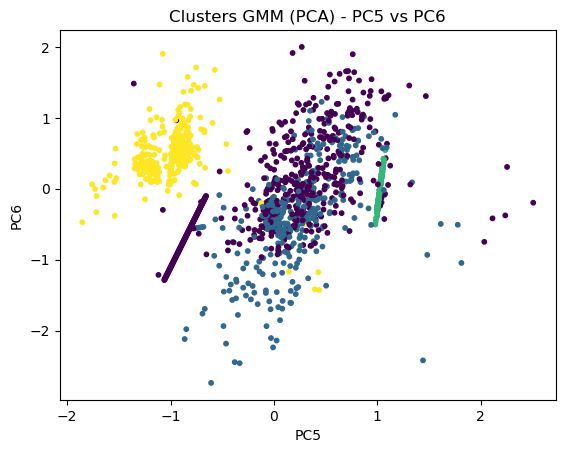

In [91]:
# --- GRAFICAR AUTOMÁTICAMENTE TODAS LAS COMBINACIONES DE COMPONENTES PRINCIPALES (PCA) ---
# Este bloque grafica automáticamente PC1 vs PC2, PC2 vs PC3, ..., hasta el máximo de componentes

if use_pca and X_cluster.shape[1] >= 2:
    n_pcs = X_cluster.shape[1]
    for i in range(n_pcs - 1):
        plt.figure()
        plt.scatter(
            X_cluster[:, i],
            X_cluster[:, i + 1],
            c=labels_manual,
            cmap='viridis',
            s=10
        )
        plt.title(f'Clusters GMM (PCA) - PC{i+1} vs PC{i+2}')
        plt.xlabel(f'PC{i+1}')
        plt.ylabel(f'PC{i+2}')
        plt.show()
else:
    print('No hay suficientes componentes principales para graficar combinaciones.')
